In [3]:
import numpy as np
import pandas as pd

# read this path C:\Users\makumarm\Documents\ResearchWork\EdgeAI_IISC\Project\Hackthon\guardian-edge\Data\riding_final_data.csv
import os
data_dir = r"C:\Users\makumarm\Documents\ResearchWork\EdgeAI_IISC\Project\Hackthon\guardian-edge\Data\riding_final_data.csv"
dataFrame = pd.read_csv(data_dir)

print(dataFrame.head())


   window_id  DeviceA_ax_max  DeviceA_ax_min  DeviceA_ax_mean  DeviceA_ay_max  \
0        NaN        0.013916       -0.011597        -0.000347        0.073853   
1        NaN        0.017212       -0.013916         0.000126        0.094360   
2        NaN        0.017212       -0.013916         0.000919        0.094360   
3        NaN        0.017212       -0.027222        -0.000272        0.098755   
4        NaN        0.017212       -0.027222         0.000371        0.098755   

   DeviceA_ay_min  DeviceA_ay_mean  DeviceA_az_max  DeviceA_az_min  \
0       -0.062378        -0.002838        0.057129       -0.045410   
1       -0.081054        -0.000214        0.066162       -0.058594   
2       -0.081054         0.004333        0.066162       -0.058594   
3       -0.145874        -0.000952        0.066162       -0.058594   
4       -0.145874         0.002120        0.066162       -0.058594   

   DeviceA_az_mean  ...  DeviceB_gx_max  DeviceB_gx_min  DeviceB_gx_mean  \
0         0.0029

In [7]:
# Import required libraries
import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Prepare the data
# Select specific 6 features: max values of ax, ay, az for both devices
feature_cols = [
    'DeviceA_ax_max', 
    'DeviceA_ay_max', 
    'DeviceA_az_max', 
    'DeviceB_ax_max', 
    'DeviceB_ay_max', 
    'DeviceB_az_max'
]

X = dataFrame[feature_cols].values
y = dataFrame['activity'].values

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Activity classes: {np.unique(y)}")

# Encode labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert to one-hot encoding for softmax activation
from keras.utils import to_categorical
y_categorical = to_categorical(y_encoded, num_classes=2)

print(f"\nEncoded classes: {label_encoder.classes_}")
print(f"Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"One-hot encoded shape: {y_categorical.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Number of features: 6
Features: ['DeviceA_ax_max', 'DeviceA_ay_max', 'DeviceA_az_max', 'DeviceB_ax_max', 'DeviceB_ay_max', 'DeviceB_az_max']
X shape: (138, 6)
y shape: (138,)
Activity classes: ['falling' 'riding']

Encoded classes: ['falling' 'riding']
Class mapping: {'falling': np.int64(0), 'riding': np.int64(1)}
One-hot encoded shape: (138, 2)

Training set: (110, 6)
Testing set: (28, 6)


In [21]:
# Build Single Layer Neural Network
# Architecture: Input Layer (6 features) -> Hidden Layer (4 nodes) -> Output Layer (2 classes)

model = Sequential()

# Hidden layer with 4 nodes and ReLU activation
# Input dimension is 6 (max values of ax, ay, az for Device A and B)
model.add(Dense(3, input_dim=X_train.shape[1], activation='relu', name='hidden_layer'))

# Output layer with 2 nodes for binary classification (riding vs falling)
# Using softmax activation for classification
model.add(Dense(2, activation='softmax', name='output_layer'))

# Compile the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Display model architecture
print("Model Architecture:")
model.summary()


Model Architecture:


c:\Users\makumarm\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train the model
history = model.fit(X_train, y_train, 
                    epochs=250, 
                    batch_size=8, 
                    validation_split=0.2,
                    verbose=1)

print("\nTraining completed!")


Epoch 1/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2368 - loss: 0.6106 - val_accuracy: 0.2727 - val_loss: 0.6168
Epoch 2/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3239 - loss: 0.6114 - val_accuracy: 0.7273 - val_loss: 0.5981
Epoch 3/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6407 - loss: 0.5899 - val_accuracy: 0.9091 - val_loss: 0.5816
Epoch 4/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9033 - loss: 0.5752 - val_accuracy: 1.0000 - val_loss: 0.5668
Epoch 5/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9699 - loss: 0.5657 - val_accuracy: 1.0000 - val_loss: 0.5537
Epoch 6/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.5523 - val_accuracy: 1.0000 - val_loss: 0.5418
Epoch 7/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.5323 - val_accuracy: 1.0000 - val_loss: 0.5304
Epoch 8/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.5277 - val_accuracy: 1.0000 - 

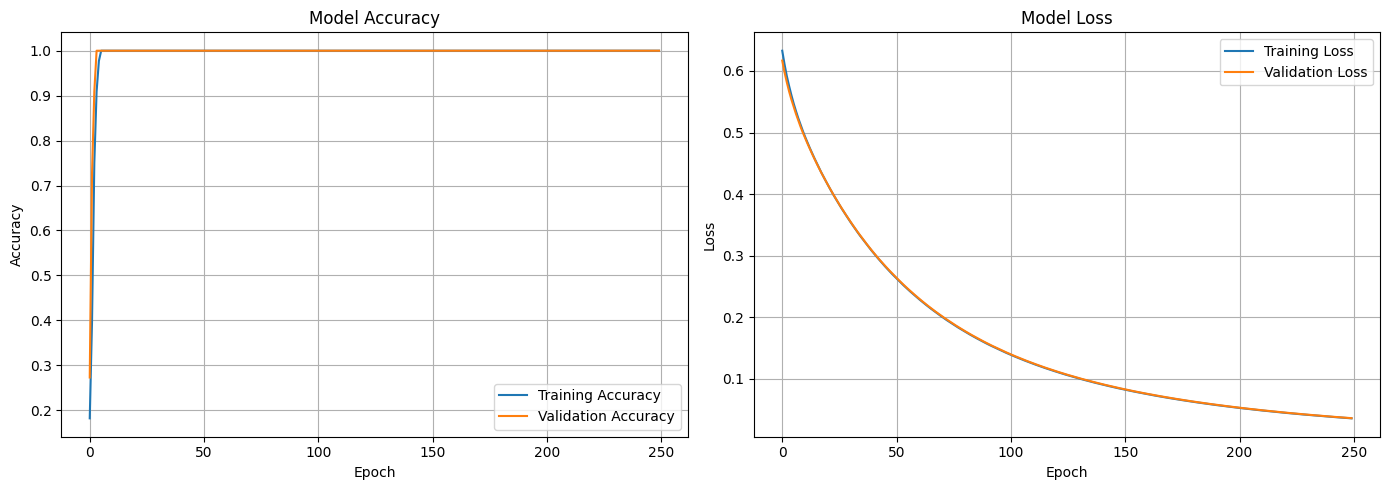

In [23]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# del model

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (360.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 60 (244.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Test Accuracy: 1.0000
Test Loss: 0.0413

Classification Report:
              precision    recall  f1-score   support

     falling     1.0000    1.0000    1.0000         2
      riding     1.0000    1.0000    1.0000        26

    accuracy                         1.0000        28
   macro avg     1.0000    1.0000    1.0000        28
weighted avg     1.0000    1.0000    1.0000        28


Confusion Matrix:
[[ 2  0]
 [ 0 26]]


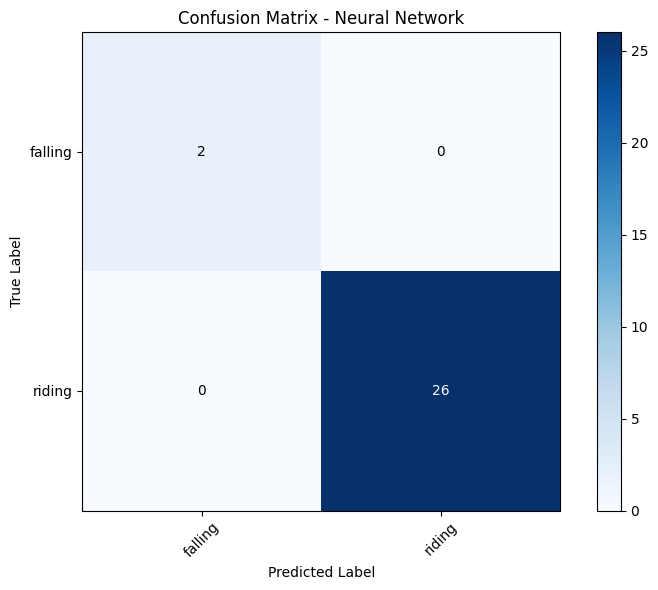

In [24]:
# Evaluate the model on test data
from sklearn.metrics import classification_report, confusion_matrix

# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Calculate accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred, target_names=label_encoder.classes_, digits=4))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_labels, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Neural Network')
plt.colorbar()
tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [20]:
# Save model weights and biases to CSV files

# Get all layer weights and biases
layer_names = ['hidden_layer', 'output_layer']

for i, layer in enumerate(model.layers):
    layer_name = layer_names[i]
    
    # Get weights and biases for this layer
    weights, biases = layer.get_weights()
    
    print(f"\n{layer_name}:")
    print(f"  Weights shape: {weights.shape}")
    print(f"  Biases shape: {biases.shape}")
    
    # Save weights to CSV
    weights_df = pd.DataFrame(weights)
    weights_file = f'{layer_name}_weights.csv'
    weights_df.to_csv(weights_file, index=False, header=False)
    print(f"  Saved weights to: {weights_file}")
    
    # Save biases to CSV
    biases_df = pd.DataFrame(biases.reshape(1, -1))
    biases_file = f'{layer_name}_biases.csv'
    biases_df.to_csv(biases_file, index=False, header=False)
    print(f"  Saved biases to: {biases_file}")

print("\n✓ All weights and biases saved successfully!")

# Display the weights and biases
print("\n" + "="*60)
print("HIDDEN LAYER WEIGHTS (6 inputs × 4 nodes):")
print("="*60)
hidden_weights, hidden_biases = model.layers[0].get_weights()
print(pd.DataFrame(hidden_weights, 
                   index=['ax_max_A', 'ay_max_A', 'az_max_A', 'ax_max_B', 'ay_max_B', 'az_max_B'],
                   columns=['Node_1', 'Node_2', 'Node_3', 'Node_4']))

print("\n" + "="*60)
print("HIDDEN LAYER BIASES:")
print("="*60)
print(pd.DataFrame(hidden_biases.reshape(1, -1), 
                   columns=['Node_1', 'Node_2', 'Node_3', 'Node_4']))

print("\n" + "="*60)
print("OUTPUT LAYER WEIGHTS (4 nodes × 2 classes):")
print("="*60)
output_weights, output_biases = model.layers[1].get_weights()
print(pd.DataFrame(output_weights,
                   index=['Node_1', 'Node_2', 'Node_3', 'Node_4'],
                   columns=['Falling', 'Riding']))

print("\n" + "="*60)
print("OUTPUT LAYER BIASES:")
print("="*60)
print(pd.DataFrame(output_biases.reshape(1, -1),
                   columns=['Falling', 'Riding']))



hidden_layer:
  Weights shape: (6, 4)
  Biases shape: (4,)
  Saved weights to: hidden_layer_weights.csv
  Saved biases to: hidden_layer_biases.csv

output_layer:
  Weights shape: (4, 2)
  Biases shape: (2,)
  Saved weights to: output_layer_weights.csv
  Saved biases to: output_layer_biases.csv

✓ All weights and biases saved successfully!

HIDDEN LAYER WEIGHTS (6 inputs × 4 nodes):
            Node_1    Node_2    Node_3    Node_4
ax_max_A -0.591661  0.100917 -0.549045  0.701337
ay_max_A  0.829679 -0.798103  0.330699  0.794406
az_max_A -0.184812  0.483957  0.043360  0.037541
ax_max_B  0.069996 -0.253046 -0.659016  0.329260
ay_max_B -0.135073  0.205611  0.476058  0.001603
az_max_B -0.583315 -0.369170 -0.168952  0.299245

HIDDEN LAYER BIASES:
     Node_1    Node_2   Node_3    Node_4
0  0.851572 -0.044099  0.68006 -0.205889

OUTPUT LAYER WEIGHTS (4 nodes × 2 classes):
         Falling    Riding
Node_1 -1.257280  1.851113
Node_2 -0.147395 -0.500308
Node_3 -1.016231  1.719363
Node_4  0.4952